where does the pre-asymptotic fast decay rate come from? -> smaller snapshots to magnify
is it numeric noise? -> rand mu
is optimum local? -> map sS vs sD for rank 10
how does discretization matter? -> vary!

In [2]:
from scipy.optimize import minimize
from scipy.optimize import direct, Bounds
from smooth_POD_ROM.post_processing import richardson_lucy
from smooth_POD_ROM.pre_processing import smoothen_rowwise
from smooth_POD_ROM.initial_conditions import rectangular_pulse, rect_pulse_sin, saw_tooth, triangle
from smooth_POD_ROM.reduced_order_model import optimize_hyperparameters, target_function
from smooth_POD_ROM.reduced_order_model import make_data_rw, get_data_rw, train_ROM_rw, L2_error_rw, get_predictions, get_improvement
import numpy as np
from smooth_POD_ROM.post_processing import get_sigma
import matplotlib.pyplot as plt
from datetime import datetime

In [3]:
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib import colormaps
from matplotlib.ticker import FormatStrFormatter
cmap = colormaps["viridis"]
page_width_pt = 455.24
pt2in = 0.01389 
pt2cm = 0.0352777778
cm2in = 1/2.54
page_width_cm = 13.70499
# TODO: work with textwidth
plot_width_in = page_width_pt*pt2in/2
page_width_in = page_width_cm*cm2in
print(plot_width_in/cm2in)

fs = 10
fs_lbl = 6
plt.rcParams["figure.figsize"] = (plot_width_in, plot_width_in/1.61803398875)
plt.rcParams["figure.autolayout"] = True
plt.rcParams['font.size'] = fs
plt.rcParams['axes.titlesize'] = fs
plt.rcParams['axes.labelsize'] = fs
plt.rcParams['xtick.labelsize'] = fs
plt.rcParams['ytick.labelsize'] = fs
plt.rcParams['legend.labelspacing'] = 0.0
plt.rcParams['legend.fontsize'] = fs_lbl
plt.rcParams['legend.handlelength'] = 1.0

plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300
mpl.rc('text', usetex=True)
mpl.rc('font', family='serif', size=fs, serif='Computer Modern Roman')
pth = "../Plots/"

markevery = 45

8.030570172000001


In [4]:
def small_saw_tooth(x, mu):
    return saw_tooth(x, mu, w=0.015)

def small_r_pulse(x, mu):
    return rectangular_pulse(x, mu, w=0.015 + 1e-6)

In [5]:
n_x = 5000
x = np.linspace(0, 1, n_x, endpoint=False)
case = {
    "n_x": n_x,
    "shape": x.shape,
    "x": x,
    "dx": x[1] - x[0],

    #"n_train": 10,
    #"n_test": 25,
    "n_val": 900,  # n_x * (n_train-1)/n_train
    "g": small_saw_tooth, #rectangular_pulse, saw_tooth, small_r_pulse
    "truncate": 12,
    "sigma": 0.08,

    "c": 1,
    "monitor_progress_postprocessing": False,
    "num_iter": 100,
    "monitor_convergence": False,
    "sigmaD": "calc_based_on_distance"
}
n_test = 10  # not in "case", because we handle it here and explicitely define mu_test

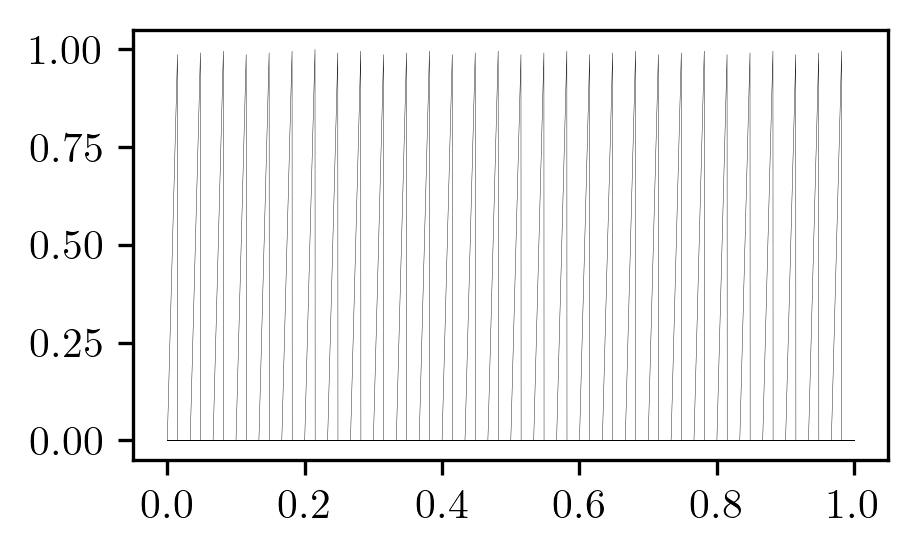

In [6]:
rank = 30
case["rank"] = n_train = rank

mu_train = np.linspace([0], [1], n_train, endpoint=False)
case["mu_train"] = mu_train

X_train, X_train_s= get_data_rw(mu_train, **case)
for i in range(len(X_train)):
    plt.plot(x, X_train[i], "k-", lw=.1)

3


C:\Repos\POD-ROM-and-gaussian-convolution\src\smooth_POD_ROM\post_processing.py:32: UserWarning: image needs to be 2D
  warnings.warn("image needs to be 2D")


100, 0.41716667, 5.00000000, 0.08111363, 0.07004232, 0.07009644, -13.5824
100, 0.69461111, 5.00000000, 0.08111363, 0.07007714, 0.07007716, -13.6062
100, 0.13972222, 5.00000000, 0.08111363, 0.06947594, 0.06789888, -16.2917
100, 0.41716667, 8.33333333, 0.08111363, 0.07004232, 0.07006213, -13.6247
100, 0.41716667, 1.66666667, 0.08111363, 0.07004232, 0.07007924, -13.6036
100, 0.13972222, 8.33333333, 0.08111363, 0.06947594, 0.06874949, -15.2430
100, 0.13972222, 1.66666667, 0.08111363, 0.06947594, 0.06923591, -14.6433
100, 0.69461111, 8.33333333, 0.08111363, 0.07007714, 0.07007716, -13.6062
100, 0.69461111, 1.66666667, 0.08111363, 0.07007714, 0.07007735, -13.6060
100, 0.23220370, 5.00000000, 0.08111363, 0.06974269, 0.07008167, -13.6006
100, 0.04724074, 5.00000000, 0.08111363, 0.06991422, 0.07378440, -9.0358
100, 0.13972222, 6.11111111, 0.08111363, 0.06947594, 0.06798485, -16.1857
100, 0.13972222, 3.88888889, 0.08111363, 0.06947594, 0.06829322, -15.8055
100, 0.23220370, 6.11111111, 0.08111363

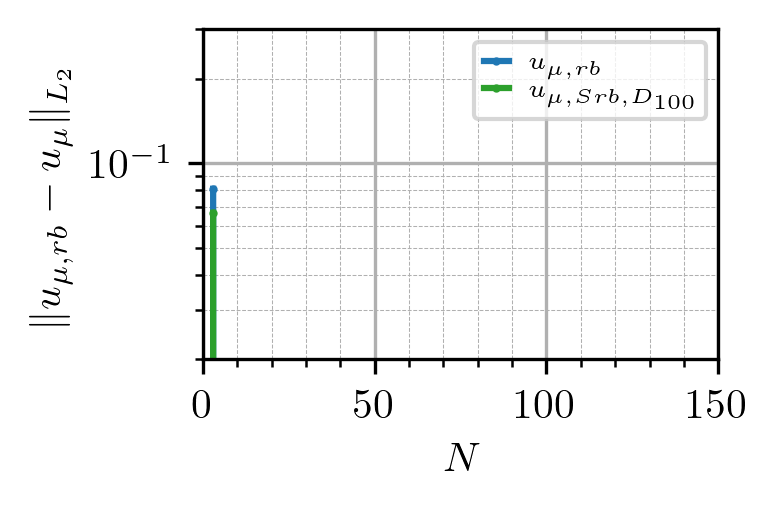

5
100, 0.25050000, 5.00000000, 0.08100833, 0.06966985, 0.07014930, -13.4048
100, 0.41683333, 5.00000000, 0.08100833, 0.06998651, 0.07003540, -13.5454
100, 0.08416667, 5.00000000, 0.08100833, 0.06875506, 0.06487945, -19.9101
100, 0.25050000, 8.33333333, 0.08100833, 0.06966985, 0.06976074, -13.8845
100, 0.25050000, 1.66666667, 0.08100833, 0.06966985, 0.06922662, -14.5438
100, 0.08416667, 8.33333333, 0.08100833, 0.06875506, 0.06398860, -21.0098
100, 0.08416667, 1.66666667, 0.08100833, 0.06875506, 0.06537063, -19.3038
100, 0.41683333, 8.33333333, 0.08100833, 0.06998651, 0.07000799, -13.5793
100, 0.41683333, 1.66666667, 0.08100833, 0.06998651, 0.07006730, -13.5061
100, 0.13961111, 8.33333333, 0.08100833, 0.06916419, 0.06815089, -15.8717
100, 0.02872222, 8.33333333, 0.08100833, 0.06941444, 0.06962515, -14.0519
100, 0.08416667, 9.44444444, 0.08100833, 0.06875506, 0.06512076, -19.6123
100, 0.08416667, 7.22222222, 0.08100833, 0.06875506, 0.06401357, -20.9790
100, 0.13961111, 7.22222222, 0.08100

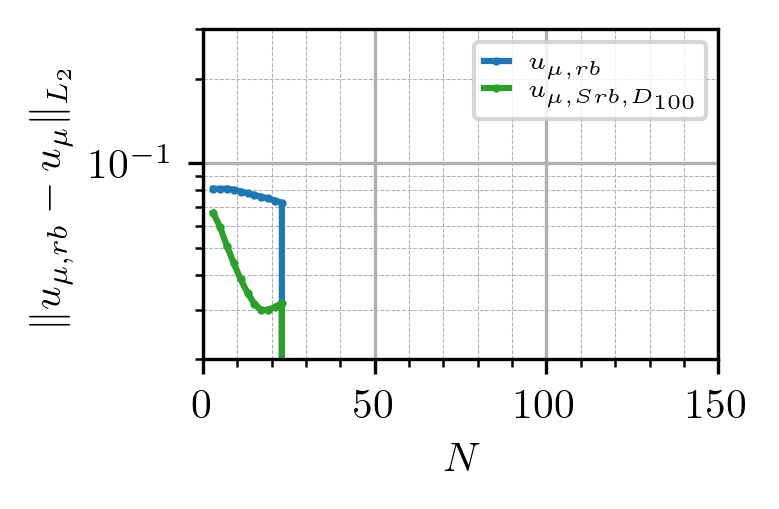

25
100, 0.05050000, 5.00000000, 0.07052282, 0.06625087, 0.05335545, -24.3430
100, 0.08350000, 5.00000000, 0.07052282, 0.06773203, 0.06136990, -12.9787
100, 0.01750000, 5.00000000, 0.07052282, 0.06173530, 0.03193135, -54.7220
100, 0.05050000, 8.33333333, 0.07052282, 0.06625087, 0.05615084, -20.3792
100, 0.05050000, 1.66666667, 0.07052282, 0.06625087, 0.05057631, -28.2838
100, 0.01750000, 8.33333333, 0.07052282, 0.06173530, 0.03608316, -48.8348
100, 0.01750000, 1.66666667, 0.07052282, 0.06173530, 0.03743938, -46.9117
100, 0.08350000, 8.33333333, 0.07052282, 0.06773203, 0.06202375, -12.0515
100, 0.08350000, 1.66666667, 0.07052282, 0.06773203, 0.05938552, -15.7925
100, 0.02850000, 5.00000000, 0.07052282, 0.06384050, 0.04183530, -40.6783
100, 0.00650000, 5.00000000, 0.07052282, 0.06219309, 0.07287428, 3.3343
100, 0.01750000, 6.11111111, 0.07052282, 0.06173530, 0.03326722, -52.8277
100, 0.01750000, 3.88888889, 0.07052282, 0.06173530, 0.03100272, -56.0387
100, 0.02850000, 3.88888889, 0.070522

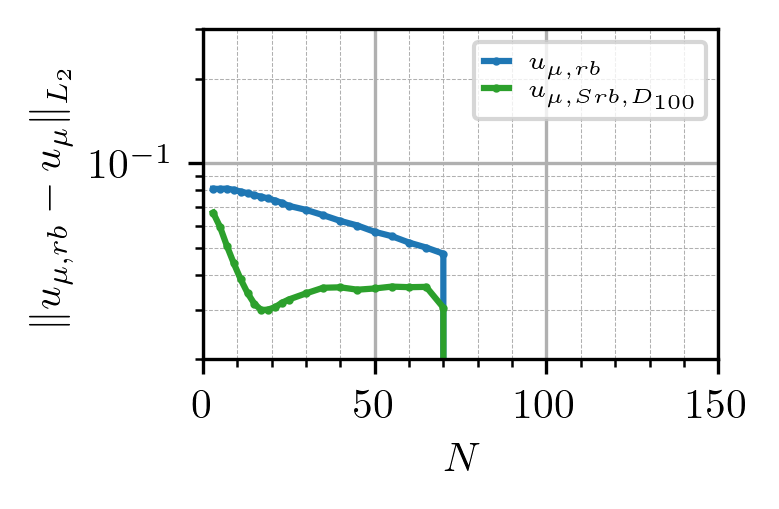

80
100, 0.01612500, 5.00000000, 0.04386917, 0.05797741, 0.02959166, -32.5457
100, 0.02620833, 5.00000000, 0.04386917, 0.06260937, 0.03864023, -11.9194
100, 0.00604167, 5.00000000, 0.04386917, 0.04555332, 0.04054227, -7.5837
100, 0.01612500, 8.33333333, 0.04386917, 0.05797741, 0.03299614, -24.7851
100, 0.01612500, 1.66666667, 0.04386917, 0.05797741, 0.02875751, -34.4471
100, 0.02620833, 1.66666667, 0.04386917, 0.06260937, 0.03348140, -23.6790
100, 0.00604167, 1.66666667, 0.04386917, 0.04555332, 0.03615650, -17.5811
100, 0.02620833, 8.33333333, 0.04386917, 0.06260937, 0.04358544, -0.6468
100, 0.00604167, 8.33333333, 0.04386917, 0.04555332, 0.03792472, -13.5504
100, 0.01948611, 1.66666667, 0.04386917, 0.05999117, 0.02834899, -35.3783
100, 0.01276389, 1.66666667, 0.04386917, 0.05515112, 0.03309620, -24.5570
100, 0.01612500, 2.77777778, 0.04386917, 0.05797741, 0.02862650, -34.7457
100, 0.01612500, 0.55555556, 0.04386917, 0.05797741, 0.02827121, -35.5556
100, 0.01948611, 0.55555556, 0.043869

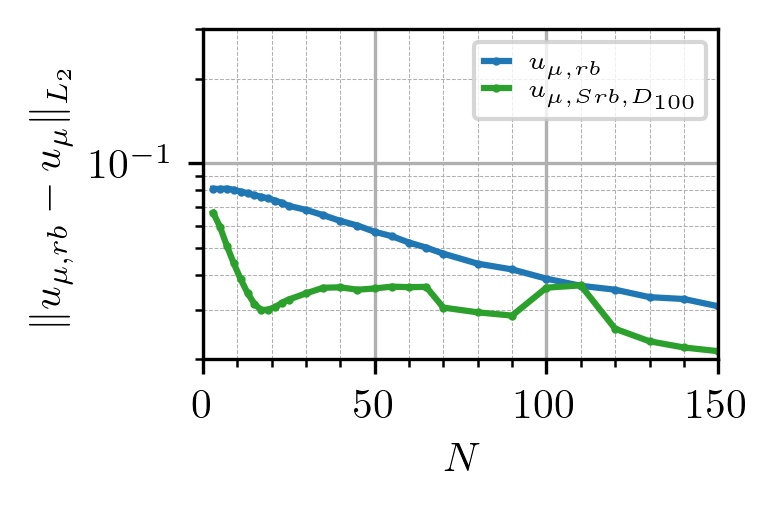

180
100, 0.00744444, 5.00000000, 0.02893607, 0.04490207, 0.03930552, 35.8357
100, 0.01174074, 5.00000000, 0.02893607, 0.05298880, 0.03189883, 10.2390
100, 0.00314815, 5.00000000, 0.02893607, 0.03125522, 0.04382784, 51.4644
100, 0.00744444, 8.33333333, 0.02893607, 0.04490207, 0.03540710, 22.3632
100, 0.00744444, 1.66666667, 0.02893607, 0.04490207, 0.04078085, 40.9343
100, 0.01174074, 8.33333333, 0.02893607, 0.05298880, 0.03069064, 6.0636
100, 0.01174074, 1.66666667, 0.02893607, 0.05298880, 0.03594974, 24.2385
100, 0.00314815, 8.33333333, 0.02893607, 0.03125522, 0.04368290, 50.9635
100, 0.00314815, 1.66666667, 0.02893607, 0.03125522, 0.03151289, 8.9052
100, 0.01317284, 8.33333333, 0.02893607, 0.05476278, 0.03095732, 6.9852
100, 0.01030864, 8.33333333, 0.02893607, 0.05082868, 0.03130171, 8.1754
100, 0.01174074, 9.44444444, 0.02893607, 0.05298880, 0.03099264, 7.1073
100, 0.01174074, 7.22222222, 0.02893607, 0.05298880, 0.03067240, 6.0006
100, 0.01317284, 7.22222222, 0.02893607, 0.05476278, 

In [7]:
g = case["g"]

shape = case["shape"]
num_iter1 = 100
num_iter2 = 250

#def estimate_dN():

# num_iter = 200
#NN = np.array([*np.arange(4, 30, 2), *np.arange(30, 150, 10)])
NN = np.array([*np.arange(3, 25, 2), *np.arange(25, 75, 5), *np.arange(80, 200, 10)])
dN_ROM = np.zeros(len(NN))
dN_sROM = np.zeros(len(NN))
dN_sROMs = np.zeros(len(NN))
dN_sROMs2 = np.zeros(len(NN))
dN_sig = np.zeros(len(NN))
dN_c = np.zeros(len(NN))

for i, rank in enumerate(NN):
    print(rank)
    case["num_iter"] = num_iter1
    case["rank"] = n_train = rank
    
    mu_min, mu_max = np.array([0]), np.array([1])
    # mu_train = np.atleast_2d(np.random.rand(n_train,)[:, None] * (mu_max - mu_min) + mu_min)
    # mu_min, mu_max = np.min(mu_train), np.max(mu_train)
    # mu_test = np.atleast_2d(np.random.rand(n_test,)[:, None] * (mu_max - mu_min) + mu_min)

    mu_train = np.linspace(mu_min, mu_max, n_train, endpoint=False)
    mu_min, mu_max = mu_train[1], mu_train[2]
    mu_test = np.linspace(mu_min, mu_max, n_test, endpoint=False)

    
    case["mu_train"], case["mu_test"] = mu_train, mu_test
    parameters = optimize_hyperparameters(case)
    case["sigma"],  case["c"]  = parameters

    case["num_iter"] = num_iter2
    X_train, X_train_s= get_data_rw(mu_train, **case)
    X_test, X_test_s  = get_data_rw(mu_test, **case)
    
    my_ROM = train_ROM_rw(mu_train, X_train)
    my_sROM = train_ROM_rw(mu_train, X_train_s)

    X_test_ROM = my_ROM.predict(mu_test).snapshots_matrix
    X_test_sROM, X_test_sROMs = get_predictions(my_sROM, mu_test, **case)
    mean_ROM, mean_sROM, mean_sROMs, improvement = get_improvement(X_test, X_test_ROM, X_test_sROM, X_test_sROMs)

    dN_ROM[i] = mean_ROM
    dN_sROM[i] = mean_sROM
    dN_sROMs[i] = mean_sROMs
    dN_sig[i] = parameters[0]
    dN_c[i] = parameters[1]

    if (i % 10) == 0:
        
        fig, ax = plt.subplots(figsize=(page_width_in / 2, page_width_in / 3))
        plt.plot(NN, dN_ROM, "C0.-", ms=2, label=r"$u_{\mu,rb}$")
        # plt.plot(NN, esROM, "C1--", ms=2, label="$u_{rb,S}$")
        plt.plot(NN, dN_sROMs, "C2.-", ms=2, label=r"$u_{\mu,Srb,D_{100}}$")
        # plt.plot(NN, dN_sROMs2, "C3.-", ms=2, label="$u_{\mu,rb,D_{1000}}$")
        # plt.plot(mu_val, esROMs2, "C3<-", ms=4, markevery=(20, markevery), label="$u_{rb,D_{100}}$")
        plt.legend()
        plt.ylabel(r"$\|u_{\mu,rb}-u_{\mu}\|_{L_2}$")
        plt.xlabel(r"$N$")
        # plt.ylim(0, 0.4)
        plt.legend()
        ax.set_xticks(np.linspace(0, 250, 26, endpoint=True), minor=True)
        ax.set_yticks(np.linspace(0, 0.4, 19, endpoint=True), minor=True)
        plt.grid(True, which="minor", linestyle="--", lw=0.25)
        plt.grid(True, which="major", linestyle="-")
        ax.set_yscale("log")
        plt.xlim(0, 150)
        plt.ylim(2e-2, 0.3)
        plt.show()

In [16]:
np.save("../data/"+str(n_x)+"dN_ROM.npy", dN_ROM)
np.save("../data/"+str(n_x)+"dN_sROM.npy", dN_sROM)
np.save("../data/"+str(n_x)+"dN_sROMs.npy", dN_sROMs)
np.save("../data/"+str(n_x)+"dN_sig.npy", dN_sig)
np.save("../data/"+str(n_x)+"dN_c.npy", dN_c)

import pickle
filehandler = open("../data/"+str(n_x)+"config.pkl","wb")
pickle.dump(case, filehandler)
filehandler.close()

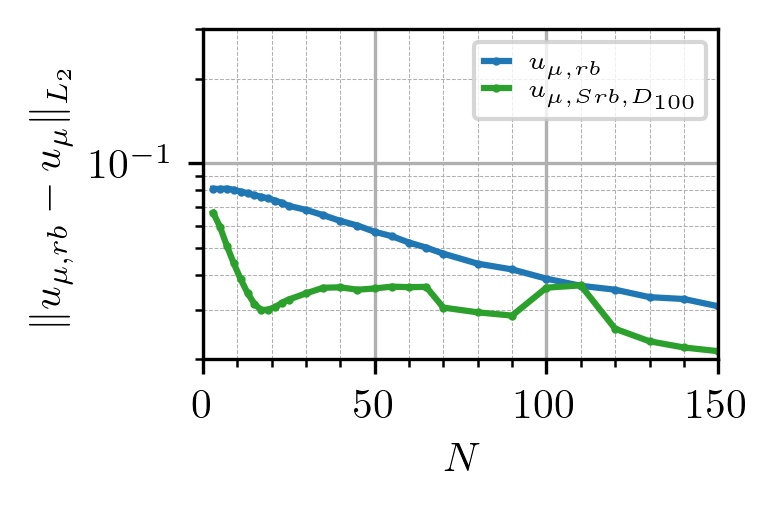

In [8]:

fig, ax = plt.subplots(figsize=(page_width_in / 2, page_width_in / 3))
plt.plot(NN, dN_ROM, "C0.-", ms=2, label=r"$u_{\mu,rb}$")
# plt.plot(NN, esROM, "C1--", ms=2, label="$u_{rb,S}$")
plt.plot(NN, dN_sROMs, "C2.-", ms=2, label=r"$u_{\mu,Srb,D_{100}}$")
# plt.plot(NN, dN_sROMs2, "C3.-", ms=2, label="$u_{\mu,rb,D_{1000}}$")
# plt.plot(mu_val, esROMs2, "C3<-", ms=4, markevery=(20, markevery), label="$u_{rb,D_{100}}$")
plt.legend()
plt.ylabel(r"$\|u_{\mu,rb}-u_{\mu}\|_{L_2}$")
plt.xlabel(r"$N$")
# plt.ylim(0, 0.4)
plt.legend()
ax.set_xticks(np.linspace(0, 250, 26, endpoint=True), minor=True)
ax.set_yticks(np.linspace(0, 0.4, 19, endpoint=True), minor=True)
plt.grid(True, which="minor", linestyle="--", lw=0.25)
plt.grid(True, which="major", linestyle="-")
ax.set_yscale("log")
plt.xlim(0, 150)
plt.ylim(2e-2, 0.3)
plt.show()

with random mu: improvement much worse

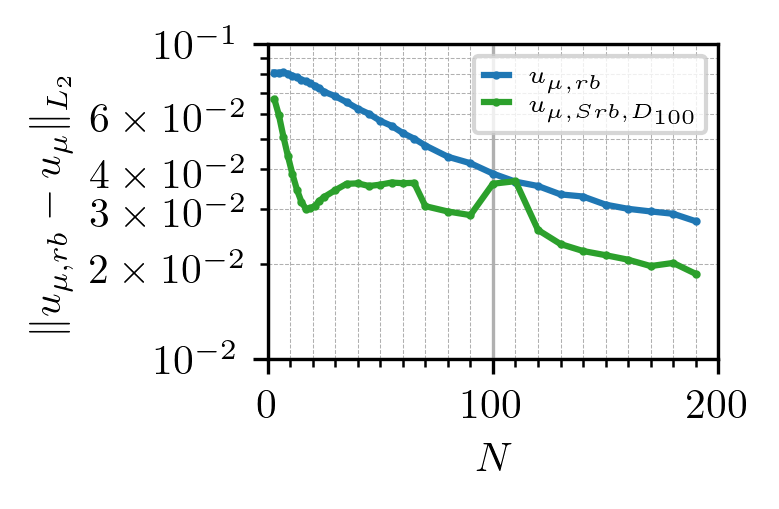

In [22]:
fig, ax = plt.subplots(figsize=(page_width_in / 2, page_width_in / 3))
plt.plot(NN, dN_ROM, "C0.-", ms=2, label=r"$u_{\mu,rb}$")
# plt.plot(NN, esROM, "C1--", ms=2, label="$u_{rb,S}$")
plt.plot(NN, dN_sROMs, "C2.-", ms=2, label=r"$u_{\mu,Srb,D_{100}}$")
# plt.plot(NN, dN_sROMs2, "C3.-", ms=2, label="$u_{\mu,rb,D_{1000}}$")
# plt.plot(mu_val, esROMs2, "C3<-", ms=4, markevery=(20, markevery), label="$u_{rb,D_{100}}$")
plt.legend()
plt.ylabel(r"$\|u_{\mu,rb}-u_{\mu}\|_{L_2}$")
plt.xlabel(r"$N$")
# plt.ylim(0, 0.4)
plt.legend()
ax.set_xticks(np.linspace(0, 250, 26, endpoint=True), minor=True)
ax.set_yticks(np.linspace(0, 0.4, 19, endpoint=True), minor=True)
plt.grid(True, which="minor", linestyle="--", lw=0.25)
plt.grid(True, which="major", linestyle="-")
ax.set_yscale("log")
plt.xlim(0, 200)
plt.ylim(1e-2, 0.1)
plt.show()

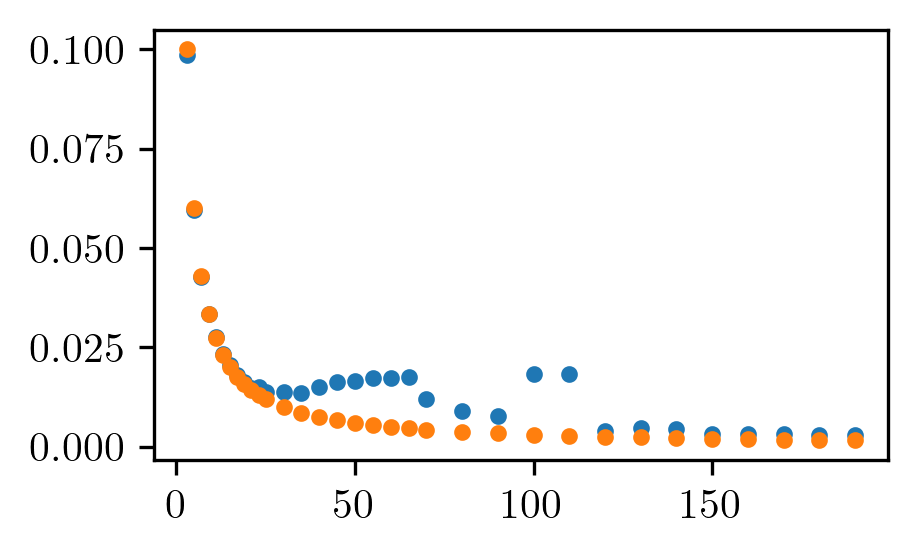

In [21]:
plt.plot(NN, dN_sig, "C0.")
plt.plot(NN, .3/NN, "C1.")

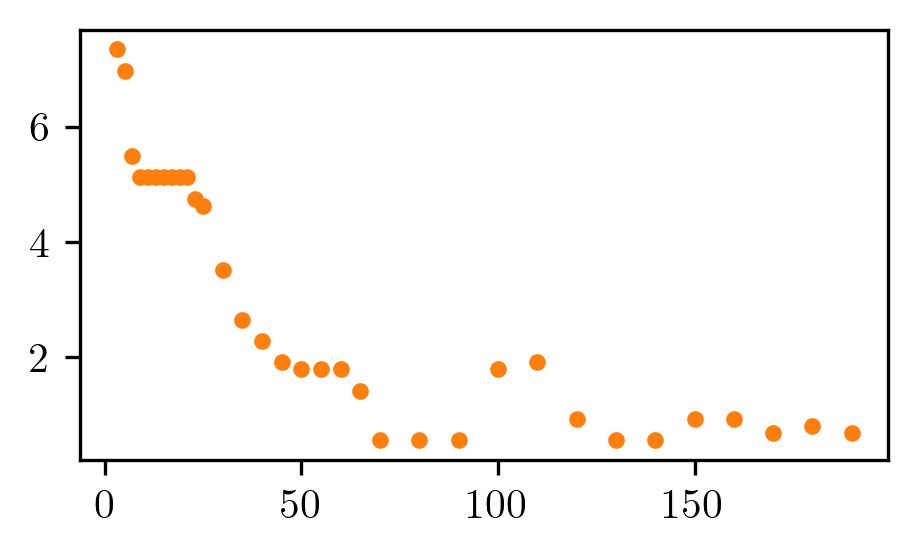

In [11]:
plt.plot(NN, dN_c, "C1.")